In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

In [ ]:

#  DEVICE CONFIGURATION

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [ ]:

# DATASET PATHS


base_path = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/resized_dataset_VGG16"

train_dir = base_path + "/train"
test_dir = base_path + "/test"

print(os.listdir(base_path))

['train', 'test']


In [ ]:

# TRANSFORMS


transform = transforms.Compose([
    transforms.ToTensor(),
])

In [ ]:

# LOAD DATASET


train_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=transform
)

print("Classes:", train_dataset.classes)
print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Classes: ['LYT', 'MON', 'NGS']
Training Images: 4500
Testing Images: 900


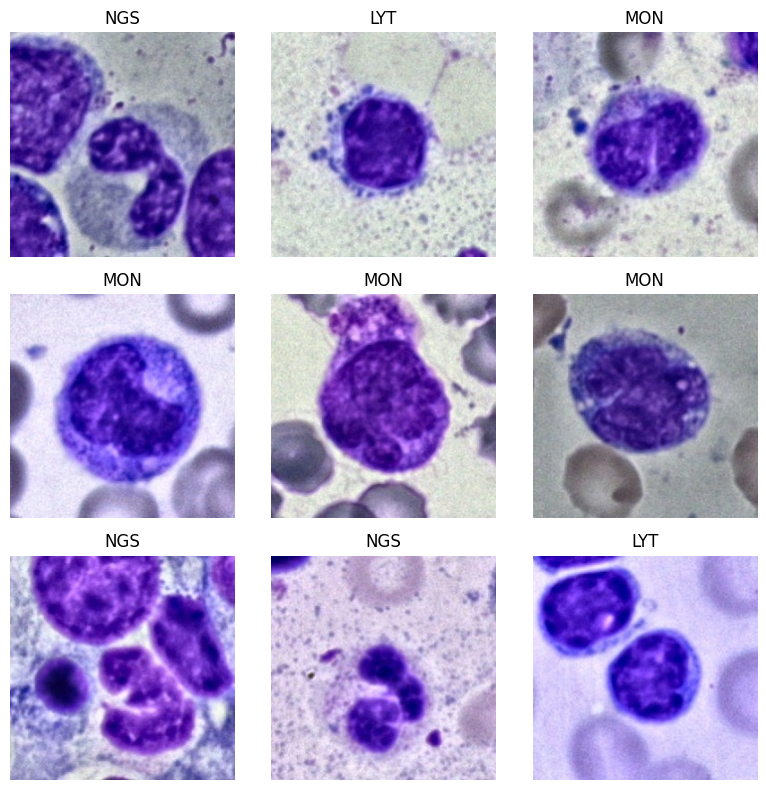

In [ ]:

#  VISUALIZE SAMPLE IMAGES

sample_loader = DataLoader(
    train_dataset,
    batch_size=9,
    shuffle=True
)

images, labels = next(iter(sample_loader))

fig, axes = plt.subplots(3, 3, figsize=(8,8))

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1,2,0)

    ax.imshow(img)

    ax.set_title(train_dataset.classes[labels[i]])

    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:

# TRAIN / VALIDATION SPLIT


train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Train Size:", len(train_data))
print("Validation Size:", len(val_data))

Train Size: 3600
Validation Size: 900


In [ ]:
#  DATALOADERS


train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:

# 9. LOAD PRETRAINED GOOGLENET


model = models.googlenet(pretrained=True)

print(model)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:

# MODIFY FINAL LAYER


num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 3)
)

model = model.to(device)

print(model.fc)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=1024, out_features=3, bias=True)
)


In [ ]:

# 12. LOSS FUNCTION & OPTIMIZER


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0001
)

In [ ]:

# EARLY STOPPING VARIABLES (new)


best_val_loss = float('inf')

patience = 5
counter = 0

num_epochs = 30

In [ ]:
checkpoint_dir = '/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/checkpoint'

os.makedirs(checkpoint_dir, exist_ok=True)

print("Checkpoint Folder Ready")

Checkpoint Folder Ready


new code block after resuming from

In [ ]:
checkpoint_path = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/checkpoint/googlenet_epoch_20.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch']

print(f"Loaded checkpoint from epoch {start_epoch}")

Loaded checkpoint from epoch 19


In [ ]:
# freeze / Unfreeze
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze Inception 5a
for param in model.inception5a.parameters():
    param.requires_grad = True

# Unfreeze Inception 5b
for param in model.inception5b.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True

print("Last inception blocks + FC layer unfrozen")

Last inception blocks + FC layer unfrozen


In [ ]:
#new optimizer

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.00001
)

print("Fine-tuning optimizer created")

Fine-tuning optimizer created


In [ ]:
# Training loop for GoogLeNet model

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Create checkpoint folder if it does not exist
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(start_epoch + 1, num_epochs):

    print(f"\nStarting Epoch {epoch+1}/{num_epochs}")

    # Set model to training mode
    model.train()

    running_loss = 0.0

    train_correct = 0
    train_total = 0

    # Loop through training batches
    for batch_idx, (images, labels) in enumerate(train_loader):

        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if batch_idx % 10 == 0:

            current_accuracy = 100 * train_correct / train_total

            print(
                f"Epoch {epoch+1} | "
                f"Batch {batch_idx}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f} | "
                f"Accuracy: {current_accuracy:.2f}%"
            )


    epoch_train_loss = running_loss / len(train_loader)

    # Calculate training accuracy
    epoch_train_accuracy = 100 * train_correct / train_total

    # Save metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Set model to evaluation mode
    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    # Disable gradients during validation
    with torch.no_grad():

        # Loop through validation batches
        for images, labels in val_loader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate validation loss
            loss = criterion(outputs, labels)

            # Add validation loss
            running_val_loss += loss.item()

            # Get predicted labels
            _, predicted = torch.max(outputs, 1)

            # Count validation accuracy
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate average validation loss
    epoch_val_loss = running_val_loss / len(val_loader)

    # Calculate validation accuracy
    epoch_val_accuracy = 100 * val_correct / val_total

    # Save validation metrics
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    # Print epoch summary
    print(f"\nEpoch [{epoch+1}/{num_epochs}] Completed")

    print(f"Training Loss: {epoch_train_loss:.4f}")
    print(f"Training Accuracy: {epoch_train_accuracy:.2f}%")

    print(f"Validation Loss: {epoch_val_loss:.4f}")
    print(f"Validation Accuracy: {epoch_val_accuracy:.2f}%")

    # Create checkpoint file path
    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"googlenet_finetune_epoch_{epoch+1}.pth"
    )

    # Save checkpoint after every epoch
    torch.save({

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'train_loss': epoch_train_loss,
        'val_loss': epoch_val_loss,

        'train_accuracy': epoch_train_accuracy,
        'val_accuracy': epoch_val_accuracy

    }, checkpoint_path)

    print("Checkpoint Saved Successfully")

    # Save best model separately
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        counter = 0

        best_model_path = os.path.join(
            checkpoint_dir,
            "best_googlenet_model.pth"
        )

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best Model Updated")

    else:

        # Increase counter if validation loss does not improve
        counter += 1

        print(f"No Improvement Count: {counter}")

        # Stop training if validation loss does not improve
        if counter >= patience:

            print("Early Stopping Triggered")

            break


Starting Epoch 21/30
Epoch 21 | Batch 0/113 | Loss: 0.6657 | Accuracy: 68.75%
Epoch 21 | Batch 10/113 | Loss: 0.7746 | Accuracy: 74.15%
Epoch 21 | Batch 20/113 | Loss: 0.6683 | Accuracy: 73.07%
Epoch 21 | Batch 30/113 | Loss: 0.6658 | Accuracy: 71.98%
Epoch 21 | Batch 40/113 | Loss: 0.5759 | Accuracy: 71.88%
Epoch 21 | Batch 50/113 | Loss: 0.5336 | Accuracy: 72.61%
Epoch 21 | Batch 60/113 | Loss: 0.5279 | Accuracy: 72.39%
Epoch 21 | Batch 70/113 | Loss: 0.6929 | Accuracy: 72.84%
Epoch 21 | Batch 80/113 | Loss: 0.6968 | Accuracy: 72.88%
Epoch 21 | Batch 90/113 | Loss: 0.6987 | Accuracy: 72.91%
Epoch 21 | Batch 100/113 | Loss: 0.6974 | Accuracy: 73.05%
Epoch 21 | Batch 110/113 | Loss: 0.9230 | Accuracy: 72.75%

Epoch [21/30] Completed
Training Loss: 0.6782
Training Accuracy: 72.64%
Validation Loss: 0.5488
Validation Accuracy: 82.11%
Checkpoint Saved Successfully
Best Model Updated

Starting Epoch 22/30
Epoch 22 | Batch 0/113 | Loss: 0.6166 | Accuracy: 71.88%
Epoch 22 | Batch 10/113 | Lo

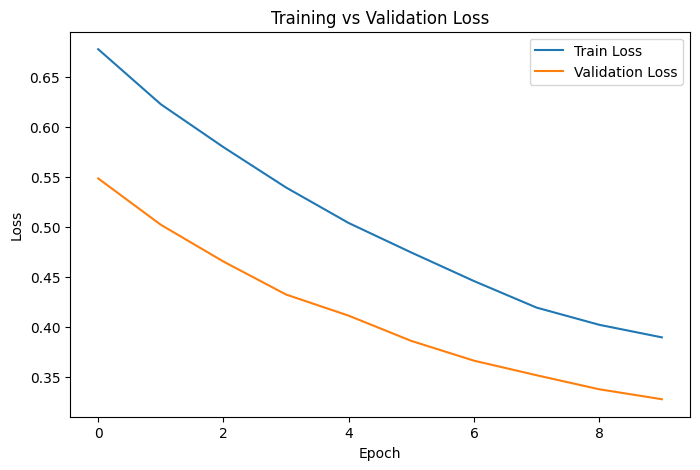

In [ ]:


plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [ ]:
best_model_path = os.path.join(
    checkpoint_dir,
    "best_googlenet_model.pth"
)

model.load_state_dict(torch.load(
    best_model_path,
    map_location=device
))

model.eval()

print("Best model loaded successfully")

Best model loaded successfully


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

print("\nStarting Model Testing...\n")

# Disable gradients during testing
with torch.no_grad():

    # Loop through test batches
    for batch_idx, (images, labels) in enumerate(test_loader):

        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predicted classes
        _, preds = torch.max(outputs, 1)

        # Store predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Calculate running accuracy
        total += labels.size(0)
        correct += (preds == labels).sum().item()

        current_accuracy = 100 * correct / total

        # Print progress every 5 batches
        if batch_idx % 5 == 0:

            print(
                f"Testing Batch {batch_idx}/{len(test_loader)} | "
                f"Current Accuracy: {current_accuracy:.2f}%"
            )

# Calculate final test accuracy
test_accuracy = accuracy_score(
    all_labels,
    all_preds
)

print("\nTesting Completed")

print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")

# Print classification report
print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
))


Starting Model Testing...

Testing Batch 0/29 | Current Accuracy: 87.50%
Testing Batch 5/29 | Current Accuracy: 89.58%
Testing Batch 10/29 | Current Accuracy: 84.94%
Testing Batch 15/29 | Current Accuracy: 84.96%
Testing Batch 20/29 | Current Accuracy: 85.27%
Testing Batch 25/29 | Current Accuracy: 85.70%

Testing Completed

Final Test Accuracy: 86.22%

Classification Report:

              precision    recall  f1-score   support

         LYT       0.87      0.86      0.87       300
         MON       0.86      0.82      0.84       300
         NGS       0.85      0.90      0.88       300

    accuracy                           0.86       900
   macro avg       0.86      0.86      0.86       900
weighted avg       0.86      0.86      0.86       900



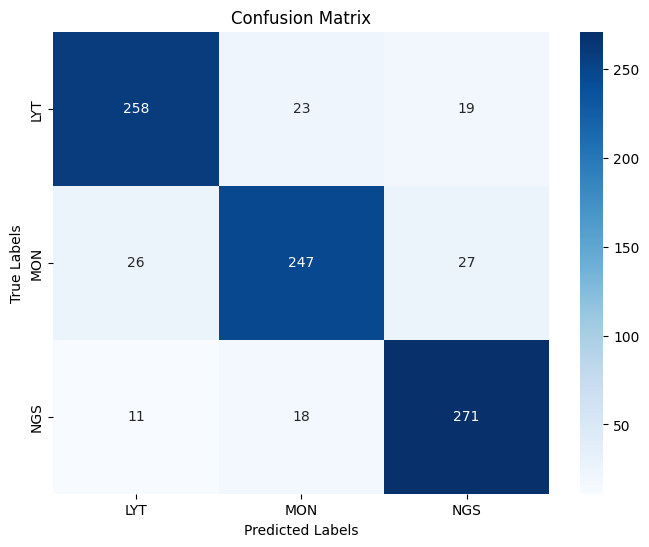

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.title("Confusion Matrix")

plt.show()

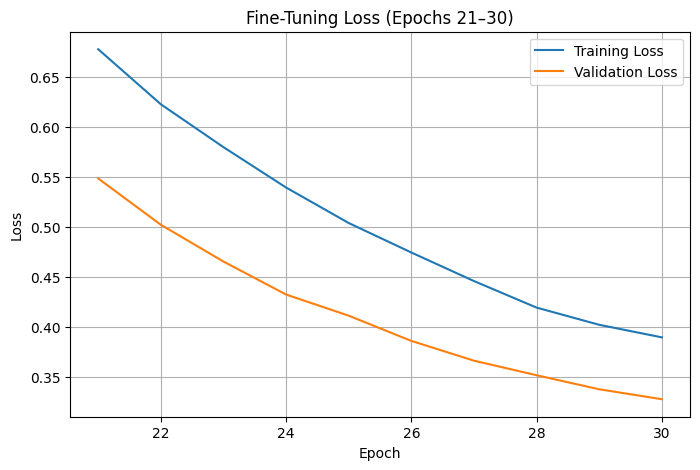

In [ ]:
epochs = range(21, 31)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss (Epochs 21–30)")
plt.legend()
plt.grid(True)
plt.show()

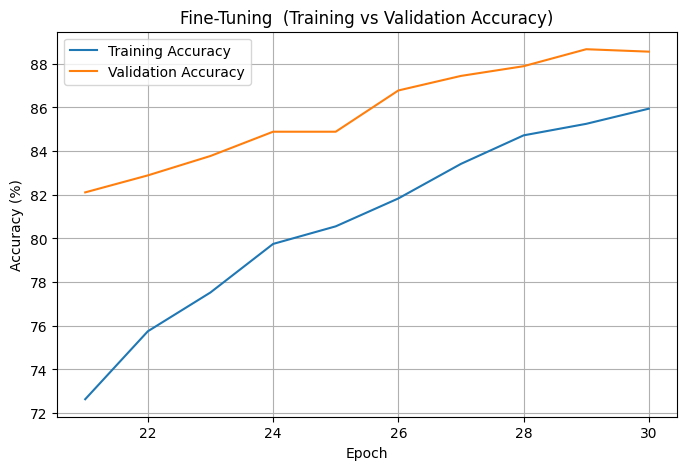

In [ ]:

epochs = range(21, 31)
plt.figure(figsize=(8,5))

plt.plot(epochs, train_accuracies, label='Training Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Fine-Tuning  (Training vs Validation Accuracy)")

plt.legend()

plt.grid(True)

plt.show()

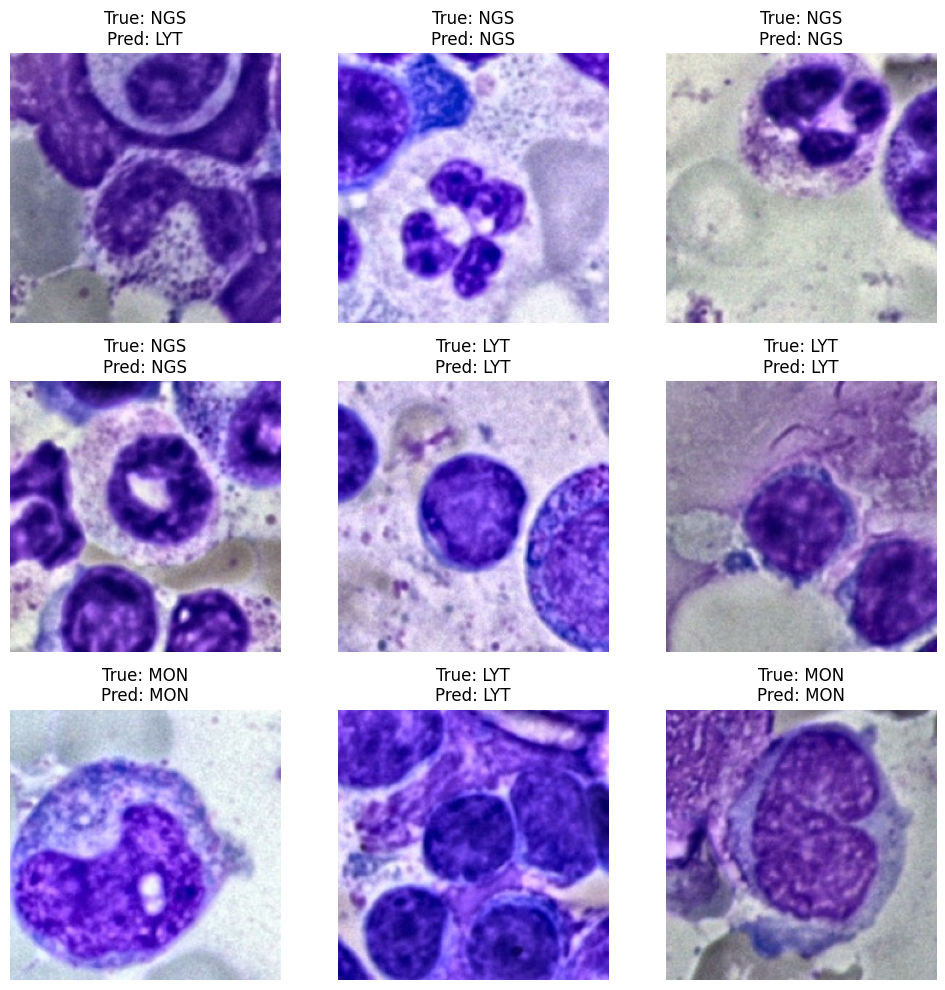

In [ ]:
import random

indices = random.sample(range(len(test_dataset)), 9)

fig, axes = plt.subplots(3,3, figsize=(10,10))

model.eval()

for ax, idx in zip(axes.flat, indices):

    image, label = test_dataset[idx]

    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_image)
        _, pred = torch.max(output, 1)

    img = image.permute(1,2,0)

    ax.imshow(img)

    true_label = test_dataset.classes[label]
    pred_label = test_dataset.classes[pred.item()]

    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}"
    )

    ax.axis('off')

plt.tight_layout()
plt.show()